In [1]:
import openmc
import openmc.model
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

from matplotlib.animation import FuncAnimation
from matplotlib.animation import FFMpegWriter

from mpl_toolkits.mplot3d import Axes3D

os.environ["OPENMC_CROSS_SECTIONS"] = \
"/home/clesio/openmcData/cross_sections.xml"

print("OpenMC Version:", openmc.__version__)

OpenMC Version: 0.15.3


In [2]:
for f in [
    "materials.xml",
    "geometry.xml",
    "plots.xml"
]:
    if os.path.exists(f):
        os.remove(f)

In [25]:
fuel_temperature = 2500.0

fuel_channel_radius = 0.35   # cm

hex_pitch = 1.20             # cm

core_height = 100.0          # cm

core_radius = 50.0           # cm

reflector_thickness = 15.0  # cm

In [26]:
fuel = openmc.Material(
    name='UC_Equivalent_Fuel'
)

fuel.temperature = fuel_temperature

fuel.add_nuclide(
    'U235',
    0.04
)

fuel.add_nuclide(
    'U238',
    0.96
)

fuel.add_element(
    'C',
    1.0
)

fuel.set_density(
    'g/cm3',
    10.5
)

In [27]:
hydrogen = openmc.Material(
    name='Hydrogen'
)

hydrogen.add_element(
    'H',
    1.0
)

hydrogen.set_density(
    'g/cm3',
    0.005
)

In [28]:
beryllium = openmc.Material(
    name='Beryllium'
)

beryllium.add_element(
    'Be',
    1.0
)

beryllium.set_density(
    'g/cm3',
    1.85
)

In [29]:
materials = openmc.Materials([
    fuel,
    hydrogen,
    beryllium
])

materials.export_to_xml()

In [30]:
top = openmc.ZPlane(
    z0=core_height/2,
    boundary_type='vacuum'
)

bottom = openmc.ZPlane(
    z0=-core_height/2,
    boundary_type='vacuum'
)

In [31]:
channel = openmc.ZCylinder(
    r=fuel_channel_radius
)

In [32]:
hex_region = -openmc.model.HexagonalPrism(
    edge_length=hex_pitch/2,
    orientation='x'
)

In [33]:
hydrogen_region = (
    -channel &
    -top &
    +bottom
)

In [34]:
fuel_region = (
    +channel &
    -top &
    +bottom
)

In [35]:
outer_boundary = openmc.ZCylinder(
    r=core_radius + reflector_thickness,
    boundary_type='vacuum'
)

top_surface = openmc.ZPlane(
    z0=core_height/2,
    boundary_type='vacuum'
)

bottom_surface = openmc.ZPlane(
    z0=-core_height/2,
    boundary_type='vacuum'
)

core_region = (
    -outer_boundary &
    -top_surface &
    +bottom_surface
)

In [36]:
hydrogen_cell = openmc.Cell(
    fill=hydrogen,
    region=hydrogen_region
)

fuel_cell = openmc.Cell(
    fill=fuel,
    region=fuel_region
)

In [37]:
fuel_element_universe = openmc.Universe()

fuel_element_universe.add_cells([
    hydrogen_cell,
    fuel_cell
])

geometry = openmc.Geometry(
    fuel_element_universe
)

geometry.export_to_xml()



In [38]:
geometry = openmc.Geometry(
    fuel_element_universe
)

geometry.export_to_xml()

In [39]:
plot = openmc.Plot()

plot.filename = "fuel_element"

plot.width = (
    2.0,
    2.0
)

plot.pixels = (
    1000,
    1000
)

plot.basis = 'xy'

plot.color_by = 'material'


In [41]:
# from IPython.display import Image

# Image("fuel_element.png")

In [42]:
plots = openmc.Plots([
    plot
])

plots.export_to_xml()

In [43]:
openmc.plot_geometry()

 Reading materials XML file...
 Reading geometry XML file...
 Preparing distributed cell instances...
 Reading plot XML file...

 =======================>     PLOTTING SUMMARY     <========================

Plot ID: 1
Plot file: fuel_element.png
Universe depth: -1
Plot Type: Slice
Origin: 0 0 0
Width:    2    2
Coloring: Materials
Basis: XY
Pixels: 1000 1000

 Processing plot 1: fuel_element.png...


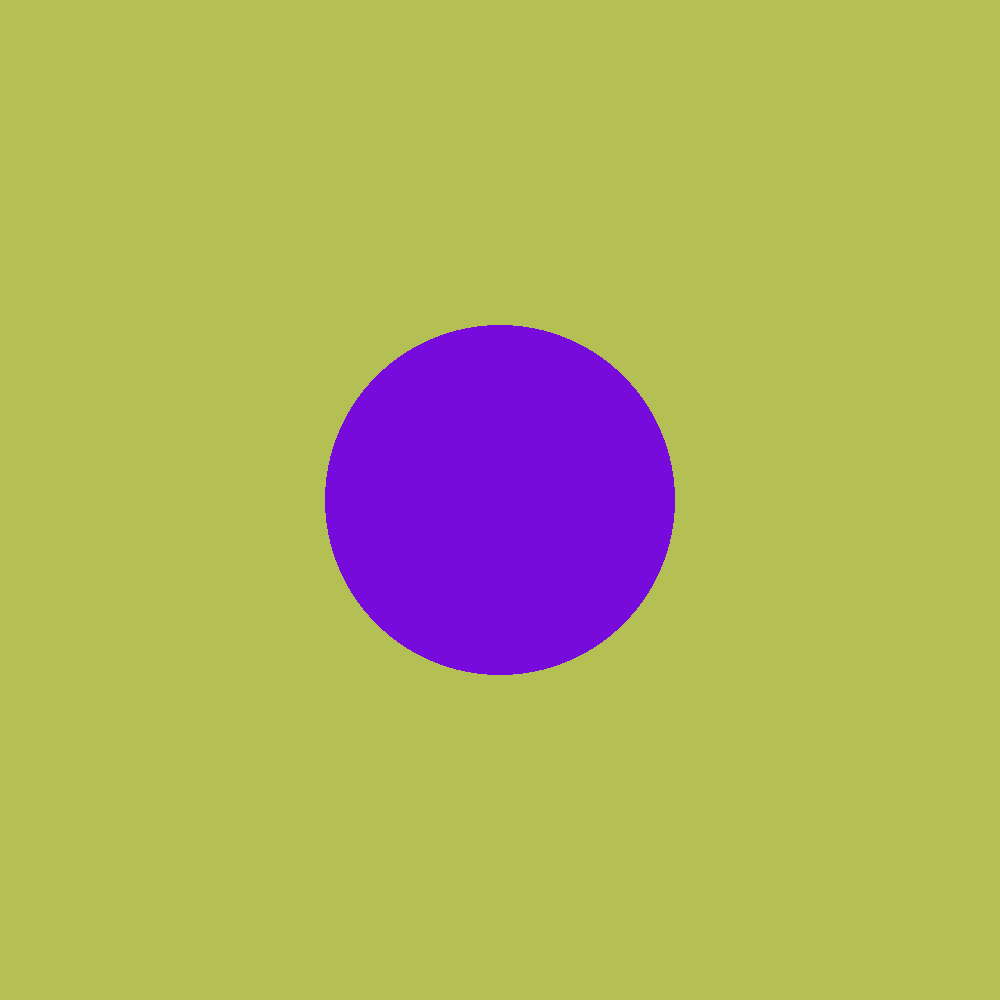

In [44]:
from IPython.display import Image

Image("fuel_element.png")

In [45]:
openmc.plot_geometry()

 Reading materials XML file...
 Reading geometry XML file...
 Preparing distributed cell instances...
 Reading plot XML file...

 =======================>     PLOTTING SUMMARY     <========================

Plot ID: 1
Plot file: fuel_element.png
Universe depth: -1
Plot Type: Slice
Origin: 0 0 0
Width:    2    2
Coloring: Materials
Basis: XY
Pixels: 1000 1000

 Processing plot 1: fuel_element.png...


In [46]:
for s in geometry.get_all_surfaces().values():
    print(
        s.id,
        s.type,
        s.boundary_type
    )

21 z-cylinder transmission
19 z-plane vacuum
20 z-plane vacuum


In [48]:
# Hydrogen channel area

hydrogen_area = np.pi * fuel_channel_radius**2

# Hexagonal fuel element area

hex_area = (
    3*np.sqrt(3)/2
) * (hex_pitch/2)**2

# Fuel matrix area

fuel_area = hex_area - hydrogen_area

# Total area

total_area = fuel_area + hydrogen_area

fuel_fraction = fuel_area / total_area

hydrogen_fraction = hydrogen_area / total_area

print(f"Fuel area      = {fuel_area:.4f} cm²")
print(f"Hydrogen area  = {hydrogen_area:.4f} cm²")
print(f"Fuel fraction  = {fuel_fraction:.4f}")
print(f"H2 fraction    = {hydrogen_fraction:.4f}")

Fuel area      = 0.5505 cm²
Hydrogen area  = 0.3848 cm²
Fuel fraction  = 0.5885
H2 fraction    = 0.4115


In [50]:
theta = np.linspace(
    0,
    2*np.pi,
    120
)

z = np.linspace(
    -core_height/2,
    core_height/2,
    120
)

Theta, Z = np.meshgrid(
    theta,
    z
)

fuel_outer_radius = hex_pitch/2

hydrogen_channel_radius = fuel_channel_radius

X_outer = fuel_outer_radius*np.cos(Theta)

Y_outer = fuel_outer_radius*np.sin(Theta)

X_inner = hydrogen_channel_radius*np.cos(Theta)

Y_inner = hydrogen_channel_radius*np.sin(Theta)

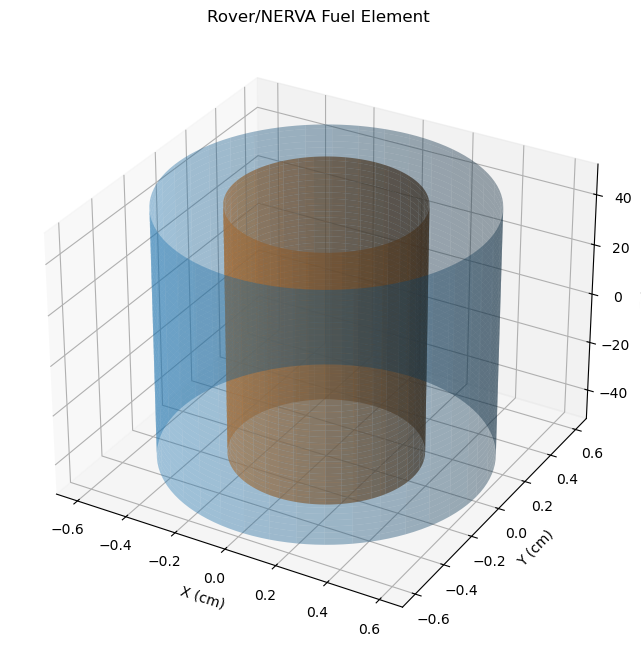

In [51]:
fig = plt.figure(
    figsize=(10,8)
)

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.plot_surface(
    X_outer,
    Y_outer,
    Z,
    alpha=0.4
)

ax.plot_surface(
    X_inner,
    Y_inner,
    Z,
    alpha=0.7
)

ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")
ax.set_zlabel("Z (cm)")

ax.set_title(
    "Rover/NERVA Fuel Element"
)

plt.show()

In [52]:
print(fuel_element_universe)

Universe
	ID             =	1
	Name           =	
	Geom           =	CSG
	Cells          =	[1, 2]



In [53]:
# Hexagonal lattice pitch

lattice_pitch = 1.20  # cm

# Number of rings

n_rings = 7

# Core dimensions

# core_radius = 12.0      # cm 

# core_height = 100.0     # cm

# reflector_thickness = 15.0  # cm

In [54]:
rings = [

    [fuel_element_universe] * 36,

    [fuel_element_universe] * 30,

    [fuel_element_universe] * 24,

    [fuel_element_universe] * 18,

    [fuel_element_universe] * 12,

    [fuel_element_universe] * 6,

    [fuel_element_universe]

]

In [55]:
lattice = openmc.HexLattice(
    name='Rover_Core_Lattice'
)

lattice.center = (0.0, 0.0)

lattice.pitch = (lattice_pitch,)

lattice.universes = rings

lattice.outer = fuel_element_universe

In [56]:
core_cylinder = openmc.ZCylinder(
    r=core_radius
)

top_boundary = openmc.ZPlane(
    z0=core_height/2,
    boundary_type='vacuum'
)

bottom_boundary = openmc.ZPlane(
    z0=-core_height/2,
    boundary_type='vacuum'
)

In [57]:
core_region = (

    -core_cylinder &

    -top_boundary &

    +bottom_boundary

)

In [58]:
core_cell = openmc.Cell(
    name='Core',
    fill=lattice,
    region=core_region
)

In [59]:
reflector_outer = openmc.ZCylinder(
    r=core_radius + reflector_thickness
)

In [60]:
reflector_region = (

    +core_cylinder &

    -reflector_outer &

    -top_boundary &

    +bottom_boundary

)

In [61]:
reflector_cell = openmc.Cell(
    name='Beryllium_Reflector',
    fill=beryllium,
    region=reflector_region
)

In [62]:
vacuum_outer = openmc.ZCylinder(
    r=core_radius + reflector_thickness,
    boundary_type='vacuum'
)

In [63]:
reflector_region = (

    +core_cylinder &

    -vacuum_outer &

    -top_boundary &

    +bottom_boundary

)

reflector_cell.region = reflector_region

In [64]:
upper_void = openmc.Cell(
    region=+top_boundary
)

In [65]:
lower_void = openmc.Cell(
    region=-bottom_boundary
)

In [66]:
root_universe = openmc.Universe(
    name='Rover_NERVA_Core'
)

root_universe.add_cells([
    core_cell,
    reflector_cell,
])

In [67]:
geometry = openmc.Geometry(
    root_universe
)

geometry.export_to_xml()

print("geometry.xml exported")

geometry.xml exported


In [68]:
plot_xy = openmc.Plot()

plot_xy.filename = "core_xy"

plot_xy.origin = (
    0.0,
    0.0,
    0.0
)

plot_xy.width = (
    140.0,
    140.0
)

plot_xy.pixels = (
    1200,
    1200
)

plot_xy.basis = 'xy'

plot_xy.color_by = 'material'

In [69]:
plot_xz = openmc.Plot()

plot_xz.filename = "core_xz"

plot_xz.origin = (
    0.0,
    0.0,
    0.0
)

plot_xz.width = (
    140.0,
    140.0
)

plot_xz.pixels = (
    1200,
    1200
)

plot_xz.basis = 'xz'

plot_xz.color_by = 'material'

In [70]:
plots = openmc.Plots([
    plot_xy,
    plot_xz
])

plots.export_to_xml()

In [71]:
openmc.plot_geometry()

 Reading materials XML file...
 Reading geometry XML file...
 Preparing distributed cell instances...
 Reading plot XML file...

 =======================>     PLOTTING SUMMARY     <========================

Plot ID: 2
Plot file: core_xy.png
Universe depth: -1
Plot Type: Slice
Origin: 0 0 0
Width:  140  140
Coloring: Materials
Basis: XY
Pixels: 1200 1200

Plot ID: 3
Plot file: core_xz.png
Universe depth: -1
Plot Type: Slice
Origin: 0 0 0
Width:  140  140
Coloring: Materials
Basis: XZ
Pixels: 1200 1200

 Processing plot 2: core_xy.png...
 Processing plot 3: core_xz.png...


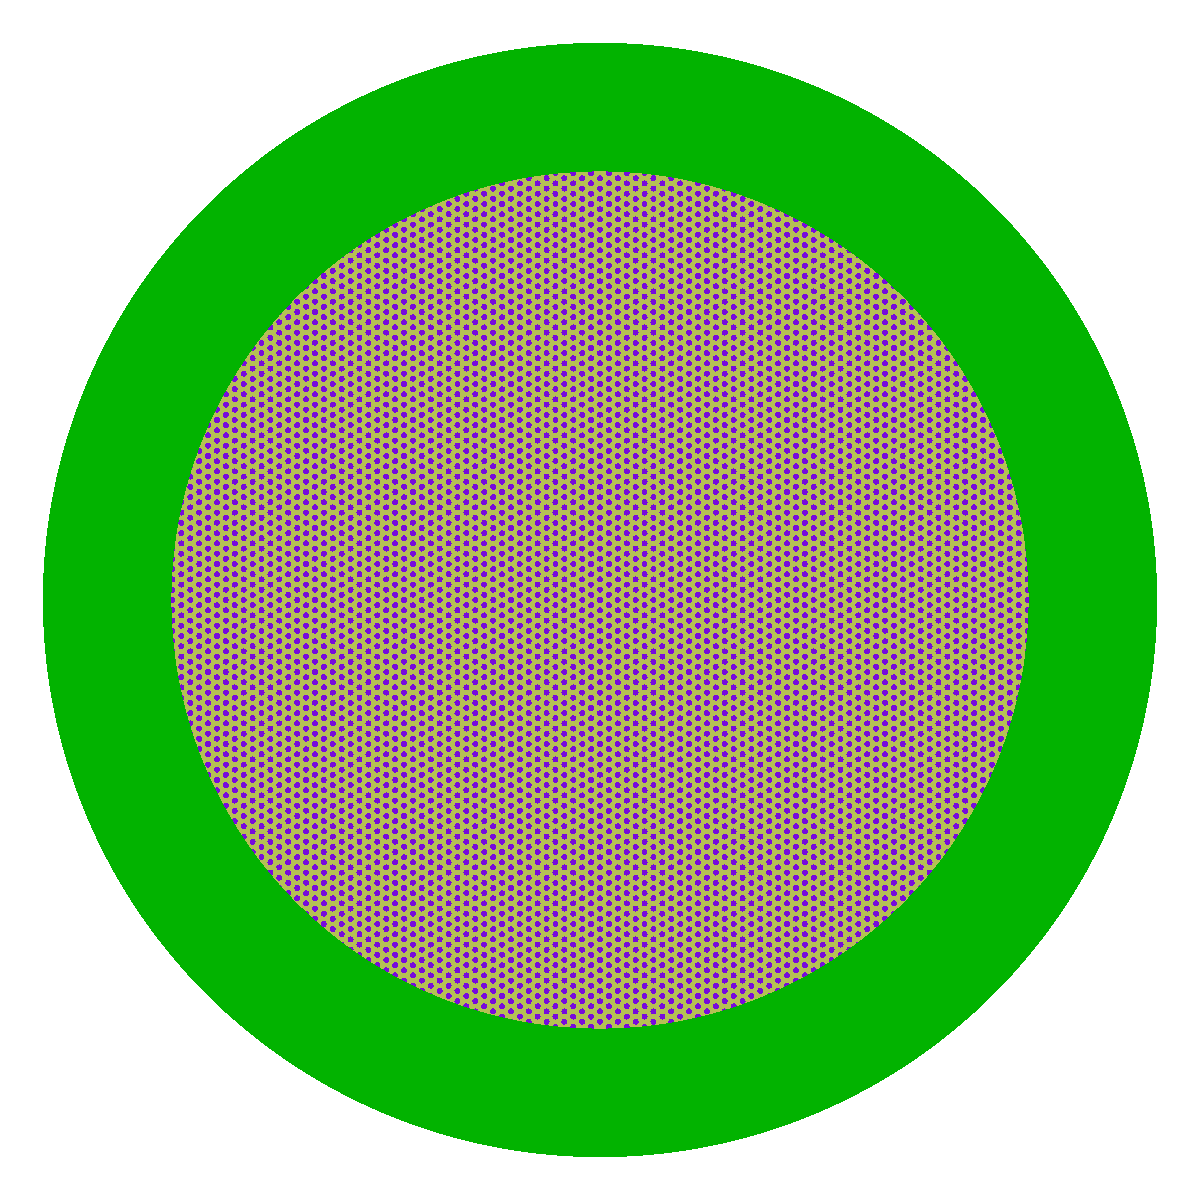

In [72]:
from IPython.display import Image

Image("core_xy.png")

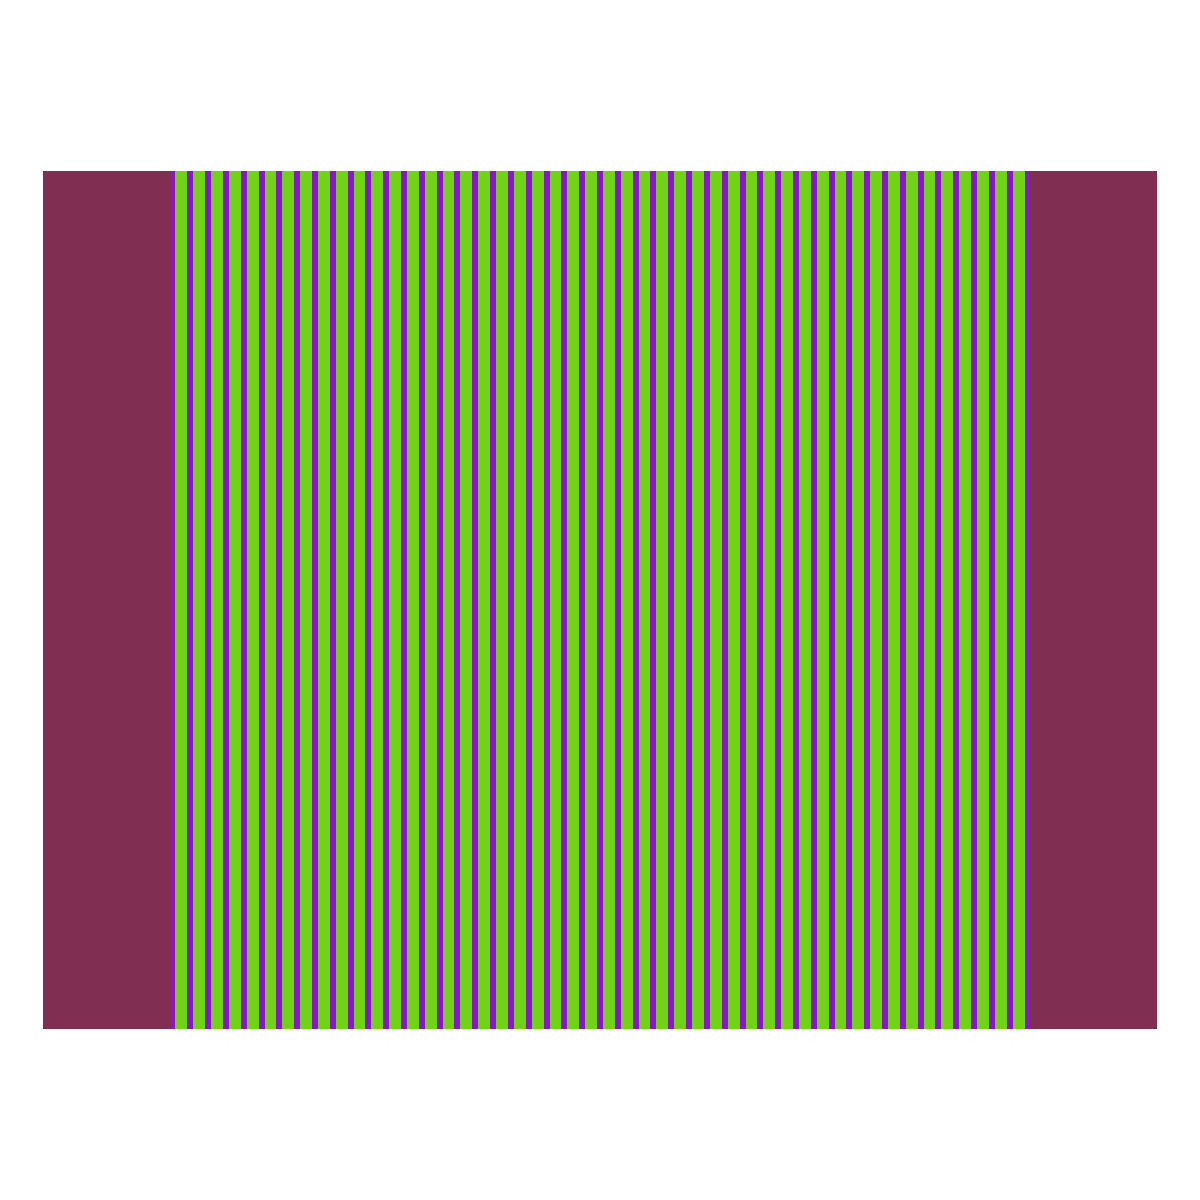

In [73]:
Image("core_xz.png")

In [74]:
fuel_elements = (
    1 +
    6 +
    12 +
    18 +
    24 +
    30 +
    36
)

print(
    "Fuel Elements =",
    fuel_elements
)

Fuel Elements = 127


In [75]:
core_volume = (
    np.pi *
    core_radius**2 *
    core_height
)

print(
    f"Core Volume = {core_volume:.2f} cm³"
)

Core Volume = 785398.16 cm³


In [76]:
reflector_volume = (

    np.pi *

    (
        (core_radius + reflector_thickness)**2 -
        core_radius**2
    )

    * core_height

)

print(
    f"Reflector Volume = {reflector_volume:.2f} cm³"
)

Reflector Volume = 541924.73 cm³


In [77]:
theta = np.linspace(
    0,
    2*np.pi,
    120
)

z = np.linspace(
    -core_height/2,
    core_height/2,
    120
)

Theta, Z = np.meshgrid(
    theta,
    z
)

In [78]:
X_core = (
    core_radius *
    np.cos(Theta)
)

Y_core = (
    core_radius *
    np.sin(Theta)
)

In [79]:
X_ref = (
    (core_radius + reflector_thickness) *
    np.cos(Theta)
)

Y_ref = (
    (core_radius + reflector_thickness) *
    np.sin(Theta)
)

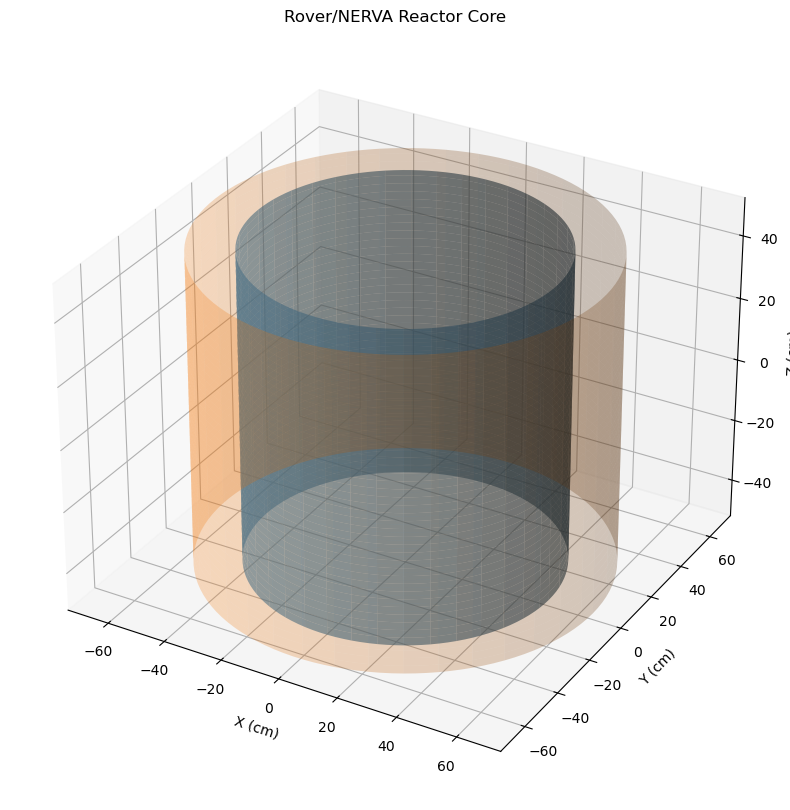

In [80]:
fig = plt.figure(
    figsize=(12,10)
)

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.plot_surface(
    X_core,
    Y_core,
    Z,
    alpha=0.6
)

ax.plot_surface(
    X_ref,
    Y_ref,
    Z,
    alpha=0.25
)

ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")
ax.set_zlabel("Z (cm)")

ax.set_title(
    "Rover/NERVA Reactor Core"
)

plt.show()

In [81]:
geometry.export_to_xml()

print("Geometry exported successfully.")

Geometry exported successfully.


In [82]:
source = openmc.IndependentSource()

source.space = openmc.stats.Box(
    (-3.0, -3.0, -20.0),
    ( 3.0,  3.0,  20.0)
)

In [83]:
settings = openmc.Settings()

settings.run_mode = "eigenvalue"

settings.particles = 50000

settings.batches = 120

settings.inactive = 30

settings.source = source


settings.max_lost_particles = 1
settings.rel_max_lost_particles = 1e-12

settings.export_to_xml()

In [84]:
settings.temperature = {
    "method": "interpolation",
    "range": (250.0, 3000.0)
}

In [85]:
settings.output = {
    "tallies": True
}

In [86]:
settings.export_to_xml()

print("settings.xml exported")

settings.xml exported


In [87]:
with open("settings.xml") as f:
    print(f.read())

<?xml version='1.0' encoding='UTF-8'?>
<settings>
  <run_mode>eigenvalue</run_mode>
  <particles>50000</particles>
  <batches>120</batches>
  <inactive>30</inactive>
  <max_lost_particles>1</max_lost_particles>
  <rel_max_lost_particles>1e-12</rel_max_lost_particles>
  <source type="independent" strength="1.0" particle="neutron">
    <space type="box">
      <parameters>-3.0 -3.0 -20.0 3.0 3.0 20.0</parameters>
    </space>
  </source>
  <output>
    <tallies>true</tallies>
  </output>
  <temperature_method>interpolation</temperature_method>
  <temperature_range>250.0 3000.0</temperature_range>
</settings>



In [88]:
energy_bins = np.logspace(
    -5,
    7,
    101
)

In [89]:
energy_filter = openmc.EnergyFilter(
    energy_bins
)

In [90]:
flux_spectrum = openmc.Tally(
    name="flux_spectrum"
)

flux_spectrum.filters = [
    energy_filter
]

flux_spectrum.scores = [
    "flux"
]

In [91]:
fission_tally = openmc.Tally(
    name="fission_rate"
)

fission_tally.scores = [
    "fission"
]

In [92]:
heating_tally = openmc.Tally(
    name="heating"
)

heating_tally.scores = [
    "heating"
]

In [93]:
mesh = openmc.RegularMesh()

mesh.dimension = (
    150,
    150,
    1
)

mesh.lower_left = (
    -core_radius,
    -core_radius,
    -1.0
)

mesh.upper_right = (
     core_radius,
     core_radius,
      1.0
)

In [94]:
mesh_filter = openmc.MeshFilter(
    mesh
)

In [95]:
flux_map = openmc.Tally(
    name="flux_map"
)

flux_map.filters = [
    mesh_filter
]

flux_map.scores = [
    "flux"
]

In [96]:
tallies = openmc.Tallies([
    flux_spectrum,
    fission_tally,
    heating_tally,
    flux_map
])

In [97]:
tallies.export_to_xml()

print("tallies.xml exported")

tallies.xml exported


In [98]:
for tally in tallies:

    print(
        tally.id,
        tally.name
    )

1 flux_spectrum
2 fission_rate
3 heating
4 flux_map


In [99]:
import os

files = [
    "materials.xml",
    "geometry.xml",
    "settings.xml",
    "tallies.xml"
]

for f in files:

    print(
        f,
        os.path.exists(f)
    )

materials.xml True
geometry.xml True
settings.xml True
tallies.xml True


In [100]:
for c in geometry.get_all_cells().values():
    print()
    print("Cell", c.id)
    print(c.name)
    print(c.region)


Cell 3
Core
(-31 -32 33)

Cell 4
Beryllium_Reflector
(31 -35 -32 33)

Cell 1

(-21 -19 20)

Cell 2

(21 -19 20)


In [101]:
print(type(hex_region))

<class 'openmc.region.Intersection'>


In [102]:
plot = openmc.Plot()

plot.filename = 'debug_cells'

plot.width = (2.5,2.5)

plot.pixels = (2000,2000)

plot.basis = 'xy'

plot.color_by = 'cell'

plots = openmc.Plots([plot])

plots.export_to_xml()

openmc.plot_geometry()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [103]:
surfaces = geometry.get_all_surfaces()



In [104]:
openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [105]:
surfaces = geometry.get_all_surfaces()



In [106]:
import glob

statepoints = sorted(
    glob.glob("statepoint.*.h5")
)

print(statepoints)

['statepoint.120.h5']


In [107]:
sp = openmc.StatePoint(
    statepoints[-1]
)

In [108]:
print()

print("k-effective")

print(sp.keff)


k-effective
0.66858+/-0.00030


In [109]:
keff_mean = sp.keff.nominal_value

keff_std = sp.keff.std_dev

print(
    f"k = {keff_mean:.5f} ± {keff_std:.5f}"
)

k = 0.66858 ± 0.00030


In [110]:
flux_tally = sp.get_tally(
    name="flux_spectrum"
)

fission_tally = sp.get_tally(
    name="fission_rate"
)

heating_tally = sp.get_tally(
    name="heating"
)

flux_map_tally = sp.get_tally(
    name="flux_map"
)

In [111]:
flux_values = (
    flux_tally.mean.flatten()
)

In [112]:
energy_mid = np.sqrt(
    energy_bins[:-1] *
    energy_bins[1:]
)

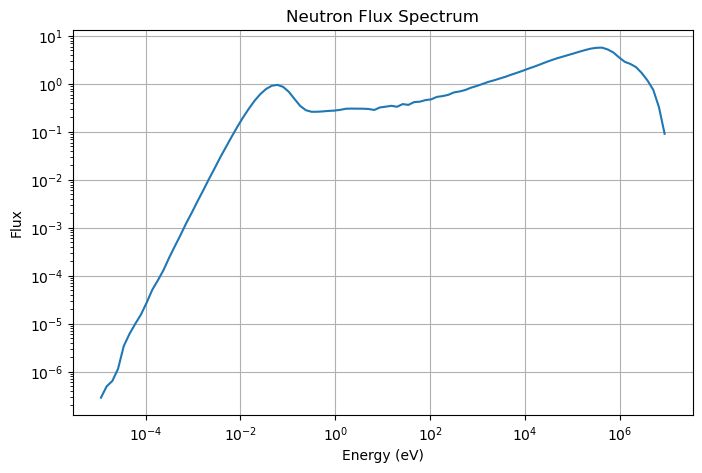

In [113]:
plt.figure(
    figsize=(8,5)
)

plt.loglog(
    energy_mid,
    flux_values
)

plt.xlabel(
    "Energy (eV)"
)

plt.ylabel(
    "Flux"
)

plt.title(
    "Neutron Flux Spectrum"
)

plt.grid(True)

plt.show()

In [114]:
heating_score = (
    heating_tally.mean.sum()
)

print()

print(
    "Heating Score =",
    heating_score
)


Heating Score = 47083923.11887709


In [115]:
fission_score = (
    fission_tally.mean.sum()
)

print()

print(
    "Fission Score =",
    fission_score
)


Fission Score = 0.2640373945844872


In [116]:
results = pd.DataFrame({

    "Quantity":[
        "k-effective",
        "Heating",
        "Fission"
    ],

    "Value":[
        keff_mean,
        heating_score,
        fission_score
    ]

})

results

,Quantity,Value
0,k-effective,6.685819e-01
1,Heating,4.708392e+07
2,Fission,2.640374e-01


In [117]:
results.to_csv(
    "rover_nerva_results.csv",
    index=False
)

print(
    "Results exported."
)

Results exported.


In [118]:
import glob

statepoint_file = sorted(
    glob.glob("statepoint.*.h5")
)[-1]

sp = openmc.StatePoint(
    statepoint_file
)

print(sp.keff)

0.66858+/-0.00030


In [119]:
flux_spectrum = sp.get_tally(
    name="flux_spectrum"
)

flux_map = sp.get_tally(
    name="flux_map"
)

fission_tally = sp.get_tally(
    name="fission_rate"
)

heating_tally = sp.get_tally(
    name="heating"
)

In [120]:
mesh_dimension = 150

In [121]:
mesh_dimension = 150

flux_mesh = flux_map.mean.reshape(
    mesh_dimension,
    mesh_dimension
)

In [122]:
print()

print("Maximum Flux")

print(flux_mesh.max())

print()

print("Average Flux")

print(flux_mesh.mean())


Maximum Flux
0.0001567105076644311

Average Flux
0.00012362568573860396


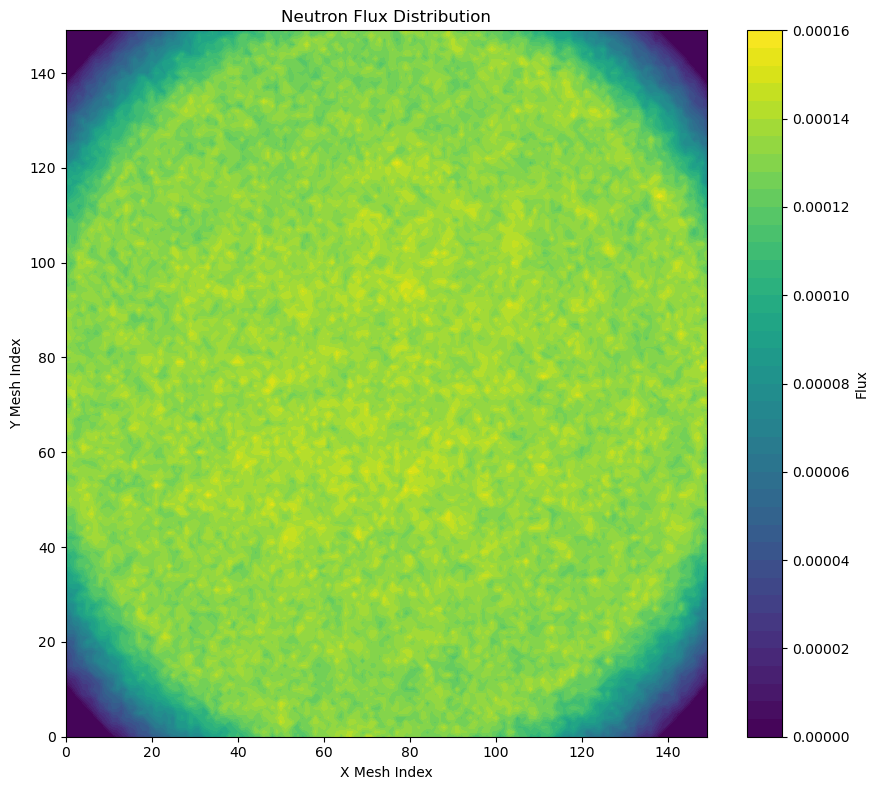

In [123]:
plt.figure(
    figsize=(9,8)
)

plt.contourf(
    flux_mesh,
    levels=50
)

plt.colorbar(
    label="Flux"
)

plt.title(
    "Neutron Flux Distribution"
)

plt.xlabel("X Mesh Index")
plt.ylabel("Y Mesh Index")

plt.tight_layout()

plt.show()

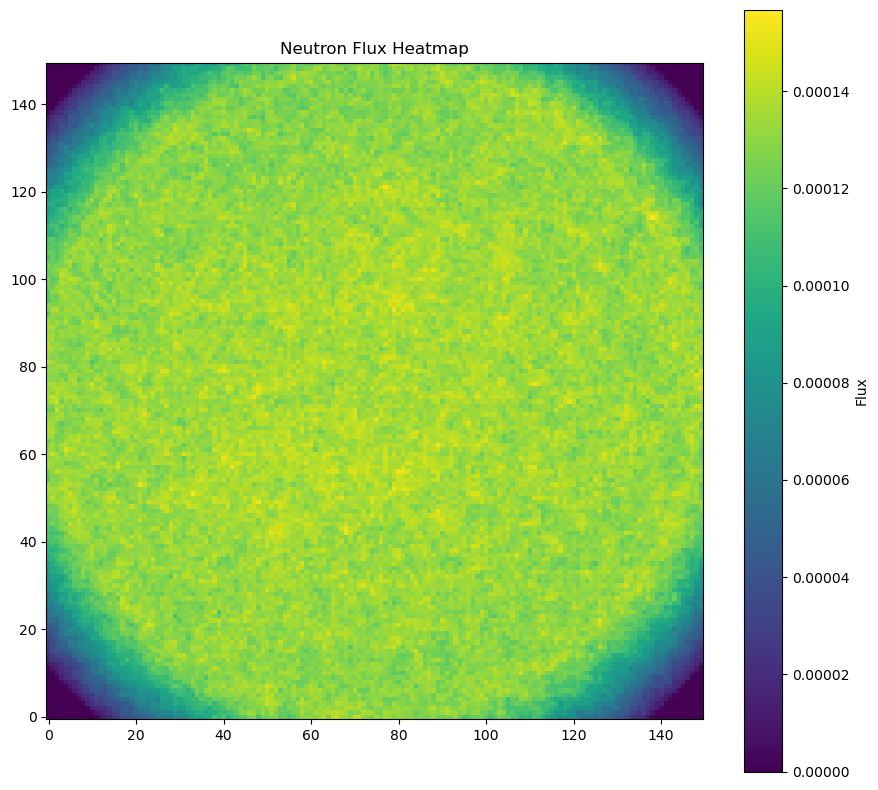

In [124]:
plt.figure(
    figsize=(9,8)
)

plt.imshow(
    flux_mesh,
    origin="lower"
)

plt.colorbar(
    label="Flux"
)

plt.title(
    "Neutron Flux Heatmap"
)

plt.tight_layout()

plt.show()

In [125]:
center = mesh_dimension//2

radial_flux = flux_mesh[
    center,
    :
]

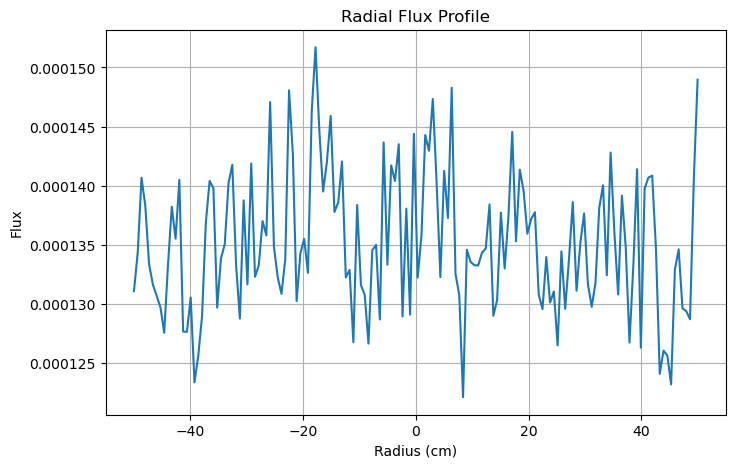

In [126]:
r = np.linspace(
    -50,
    50,
    len(radial_flux)
)

plt.figure(
    figsize=(8,5)
)

plt.plot(
    r,
    radial_flux
)

plt.xlabel(
    "Radius (cm)"
)

plt.ylabel(
    "Flux"
)

plt.title(
    "Radial Flux Profile"
)

plt.grid()

plt.show()

In [127]:
energy_bins = np.logspace(
    -5,
    7,
    101
)

energy_mid = np.sqrt(
    energy_bins[:-1] *
    energy_bins[1:]
)

flux_spectrum_values = (
    flux_spectrum.mean.flatten()
)

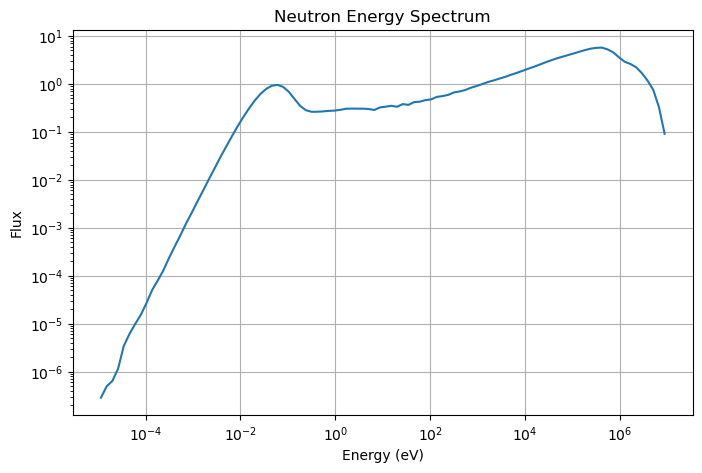

In [128]:
plt.figure(
    figsize=(8,5)
)

plt.loglog(
    energy_mid,
    flux_spectrum_values
)

plt.xlabel(
    "Energy (eV)"
)

plt.ylabel(
    "Flux"
)

plt.title(
    "Neutron Energy Spectrum"
)

plt.grid(True)

plt.show()

In [129]:
thermal_mask = energy_mid < 1.0

epithermal_mask = (
    (energy_mid >= 1.0) &
    (energy_mid < 1e5)
)

fast_mask = energy_mid >= 1e5

In [130]:
thermal_flux = np.sum(
    flux_spectrum_values[
        thermal_mask
    ]
)

epithermal_flux = np.sum(
    flux_spectrum_values[
        epithermal_mask
    ]
)

fast_flux = np.sum(
    flux_spectrum_values[
        fast_mask
    ]
)

In [131]:
total_flux = (
    thermal_flux +
    epithermal_flux +
    fast_flux
)

print()

print(
    "Thermal Fraction:",
    thermal_flux/total_flux
)

print(
    "Epithermal Fraction:",
    epithermal_flux/total_flux
)

print(
    "Fast Fraction:",
    fast_flux/total_flux
)


Thermal Fraction: 0.07732357809818767
Epithermal Fraction: 0.4181540201336993
Fast Fraction: 0.504522401768113


In [132]:
total_flux = (
    thermal_flux +
    epithermal_flux +
    fast_flux
)

print()

print(
    "Thermal Fraction:",
    thermal_flux/total_flux
)

print(
    "Epithermal Fraction:",
    epithermal_flux/total_flux
)

print(
    "Fast Fraction:",
    fast_flux/total_flux
)


Thermal Fraction: 0.07732357809818767
Epithermal Fraction: 0.4181540201336993
Fast Fraction: 0.504522401768113


In [133]:
heating_score = (
    heating_tally.mean.sum()
)

print(
    "Heating Score =",
    heating_score
)

Heating Score = 47083923.11887709


In [134]:
target_power_mw = 1000.0

normalization_factor = (
    target_power_mw /
    heating_score
)

print()

print(
    "Normalization Factor:",
    normalization_factor
)


Normalization Factor: 2.123867200860065e-05


In [135]:
power_density = (
    flux_mesh *
    normalization_factor
)

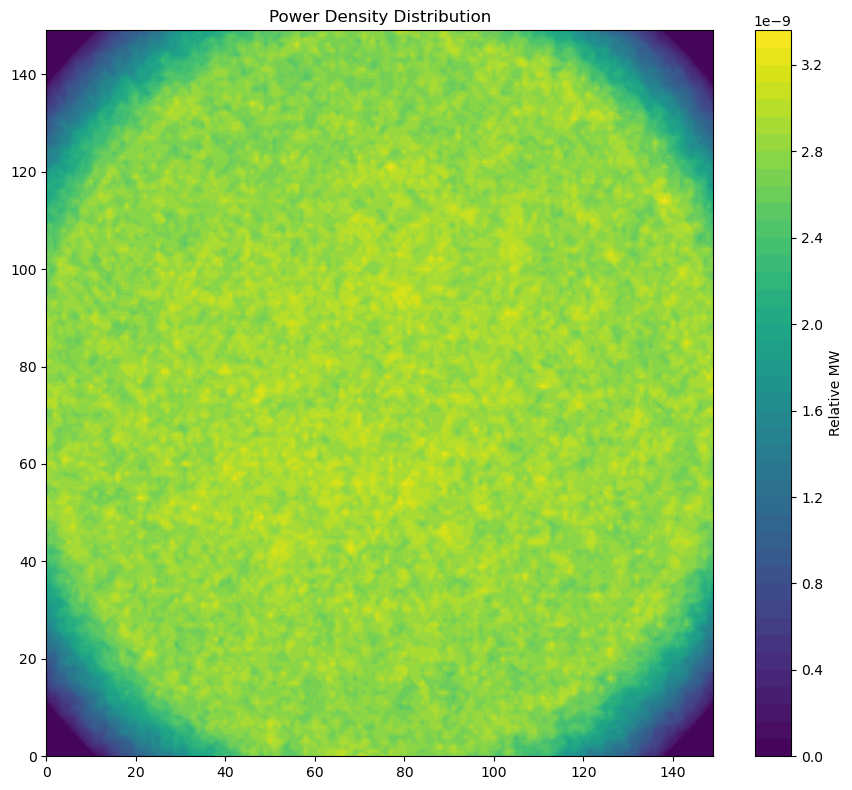

In [136]:
plt.figure(
    figsize=(9,8)
)

plt.contourf(
    power_density,
    levels=50
)

plt.colorbar(
    label="Relative MW"
)

plt.title(
    "Power Density Distribution"
)

plt.tight_layout()

plt.show()

In [137]:
X,Y = np.meshgrid(
    np.arange(mesh_dimension),
    np.arange(mesh_dimension)
)

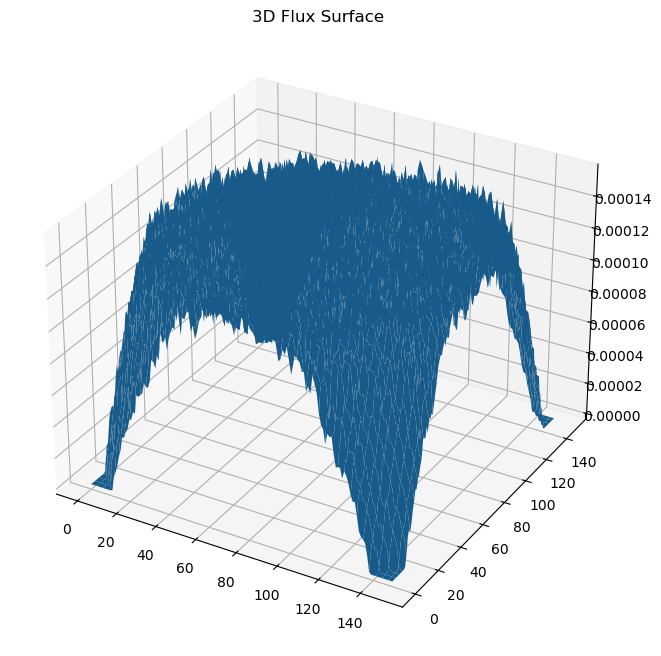

In [138]:
fig = plt.figure(
    figsize=(12,8)
)

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.plot_surface(
    X,
    Y,
    flux_mesh,
    linewidth=0
)

ax.set_title(
    "3D Flux Surface"
)

plt.show()

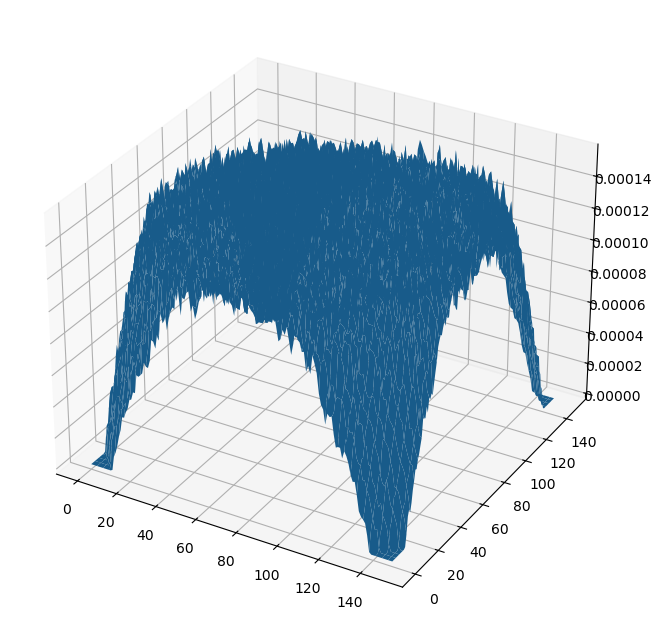

In [139]:
fig = plt.figure(
    figsize=(10,8)
)

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.plot_surface(
    X,
    Y,
    flux_mesh,
    linewidth=0
)

In [140]:
def update(angle):

    ax.view_init(
        elev=30,
        azim=angle
    )

    return fig,

In [141]:
anim = FuncAnimation(
    fig,
    update,
    frames=np.arange(
        0,
        360,
        2
    ),
    interval=50
)

In [ ]:
# sudo apt install ffmpeg

In [142]:
writer = FFMpegWriter(
    fps=30,
    bitrate=3000
)

anim.save(
    "rover_flux_surface.mp4",
    writer=writer
)

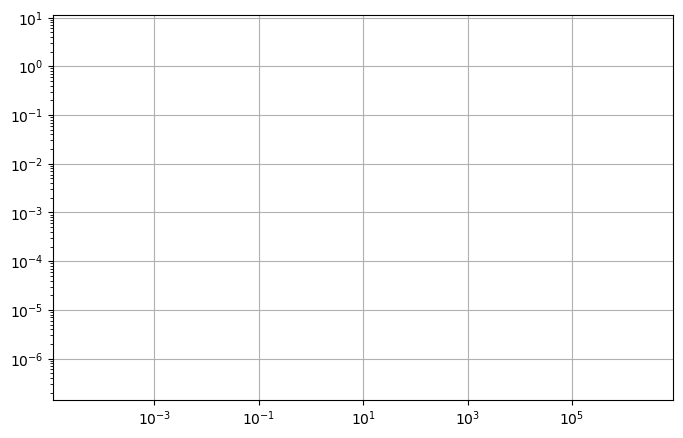

In [143]:
fig, ax = plt.subplots(
    figsize=(8,5)
)

line, = ax.loglog(
    [],
    []
)

ax.set_xlim(
    energy_mid.min(),
    energy_mid.max()
)

ax.set_ylim(
    flux_spectrum_values.min()*0.5,
    flux_spectrum_values.max()*2
)

ax.grid(True)

In [144]:
def update_spectrum(frame):

    line.set_data(
        energy_mid[:frame],
        flux_spectrum_values[:frame]
    )

    return line,

In [145]:
anim2 = FuncAnimation(
    fig,
    update_spectrum,
    frames=len(
        energy_mid
    ),
    interval=50
)

In [146]:
anim2.save(
    "rover_spectrum.mp4",
    writer=writer
)

In [147]:
summary = pd.DataFrame({

    "Parameter":[
        "k-effective",
        "Heating Score",
        "Fast Flux Fraction",
        "Thermal Flux Fraction"
    ],

    "Value":[
        sp.keff.nominal_value,
        heating_score,
        fast_flux/total_flux,
        thermal_flux/total_flux
    ]
})

summary

,Parameter,Value
0,k-effective,6.685819e-01
1,Heating Score,4.708392e+07
2,Fast Flux Fraction,5.045224e-01
3,Thermal Flux Fraction,7.732358e-02
